✅ Modèle chargé : fixed_convlstm_model.h5
✅ Scaler chargé : fixed_convlstm_target_scaler.save
337/337 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


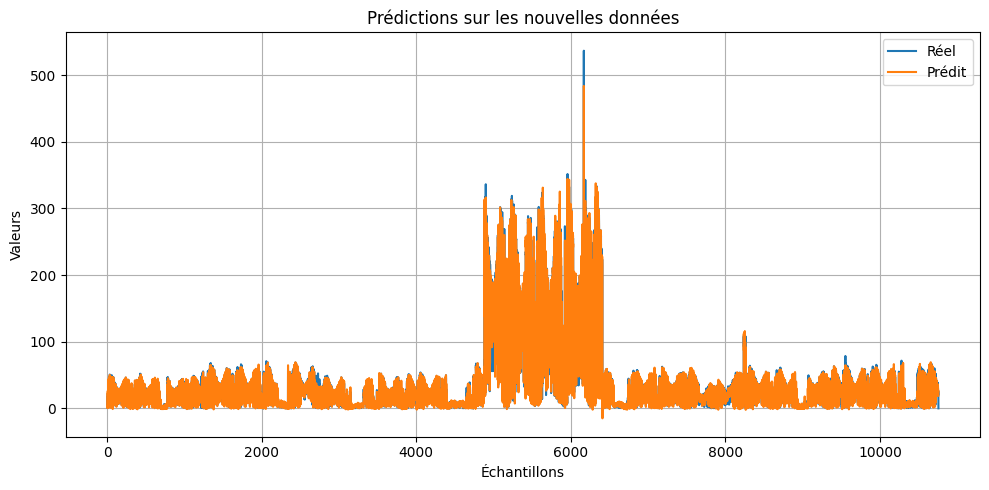

✅ Résultats sauvegardés dans new_predictions_resultats.csv


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# === PARAMÈTRES À MODIFIER SELON TON CAS ===
new_csv_path = "../DataCleaning/scaled_dataset.csv"  # Nouveau fichier CSV
model_path = "fixed_convlstm_model.h5"
scaler_path = "fixed_convlstm_target_scaler.save"
production_column = "production"
window_size = 21
output_prefix = "new_predictions"

# === 1. Charger le modèle et le scaler ===
model = load_model(model_path, compile=False)
print("✅ Modèle chargé :", model_path)

target_scaler = joblib.load(scaler_path)
print("✅ Scaler chargé :", scaler_path)

# === 2. Charger et normaliser les nouvelles données ===
df = pd.read_csv(new_csv_path)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)

target_col_idx = df.columns.get_loc(production_column)

x_new, y_new = [], []
for i in range(window_size, len(data_scaled)):
    x_new.append(data_scaled[i - window_size:i])
    y_new.append(data_scaled[i, target_col_idx])

x_new = np.array(x_new)
y_new = np.array(y_new)
x_new_conv = np.expand_dims(x_new, axis=2)

# === 3. Faire les prédictions ===
y_pred_scaled = model.predict(x_new_conv)
y_pred_real = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_real = target_scaler.inverse_transform(y_new.reshape(-1, 1)).flatten()

# === 4. Affichage courbe réelle vs prédite ===
plt.figure(figsize=(10, 5))
plt.plot(y_real, label="Réel")
plt.plot(y_pred_real, label="Prédit")
plt.title("Prédictions sur les nouvelles données")
plt.xlabel("Échantillons")
plt.ylabel("Valeurs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_prefix}_courbe_prediction.png")
plt.show()

full_df = pd.read_csv("../../DataCleaning/full_dataset_clean.csv")

# On prend uniquement les lignes utilisées après la fenêtre initiale
building_ids = full_df["building_id"].values[window_size:window_size + len(y_new)]
# === 5. Export CSV des résultats ===
results_df = pd.DataFrame({
    "building_id": building_ids,
    "Production_réelle": y_real,
    "Production_prédite": y_pred_real,
    "Erreur": y_real - y_pred_real,
    "ErreurAbs": np.abs(y_real - y_pred_real)
    })
results_df.to_csv(f"{output_prefix}_resultats.csv", index=False)
print(f"✅ Résultats sauvegardés dans {output_prefix}_resultats.csv")


In [26]:
df = pd.read_csv("new_predictions_resultats.csv")
statsdf = df.describe()
print("Statistiques des résultats :")
print(statsdf)



Statistiques des résultats :
        building_id  Production_réelle  Production_prédite        Erreur  \
count  10758.000000       10758.000000        10758.000000  10758.000000   
mean       4.844302          38.403476           38.022875      0.380601   
std        2.620494          55.810814           55.438405      5.637132   
min        1.000000           0.100000          -14.931250    -82.958813   
25%        2.000000           6.900000            6.661792     -1.101512   
50%        5.000000          23.230065           23.239888      0.256638   
75%        7.000000          40.500000           40.322228      1.690122   
max        9.000000         536.736118          483.883420     58.737630   

          ErreurAbs  
count  10758.000000  
mean       2.856789  
std        4.874437  
min        0.000101  
25%        0.601101  
50%        1.414169  
75%        2.987798  
max       82.958813  


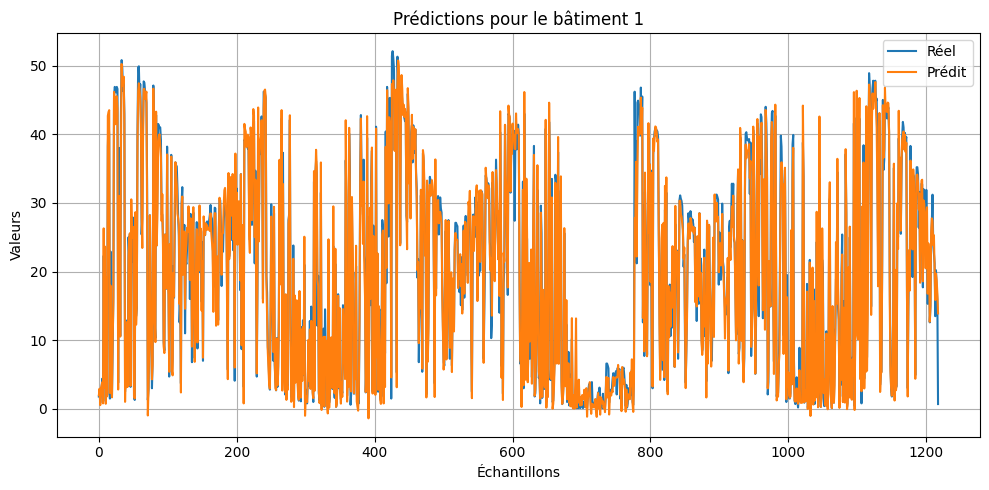

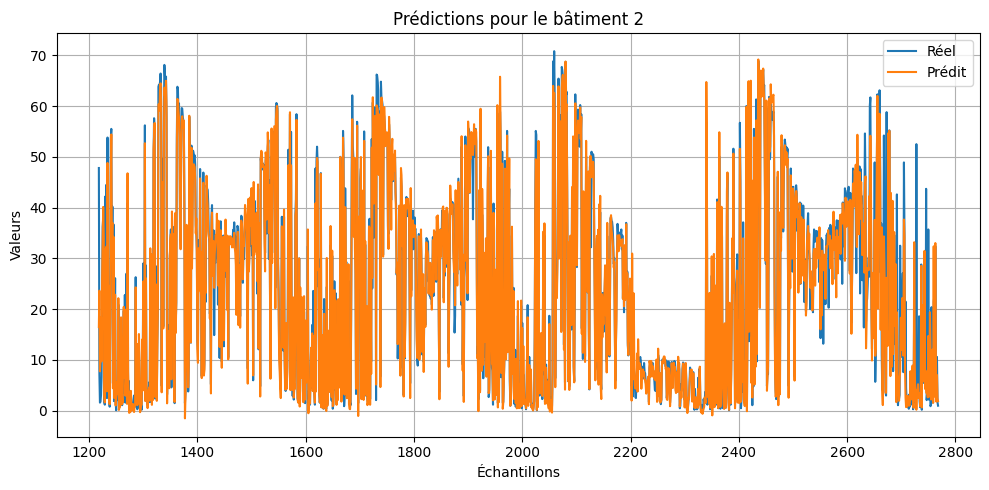

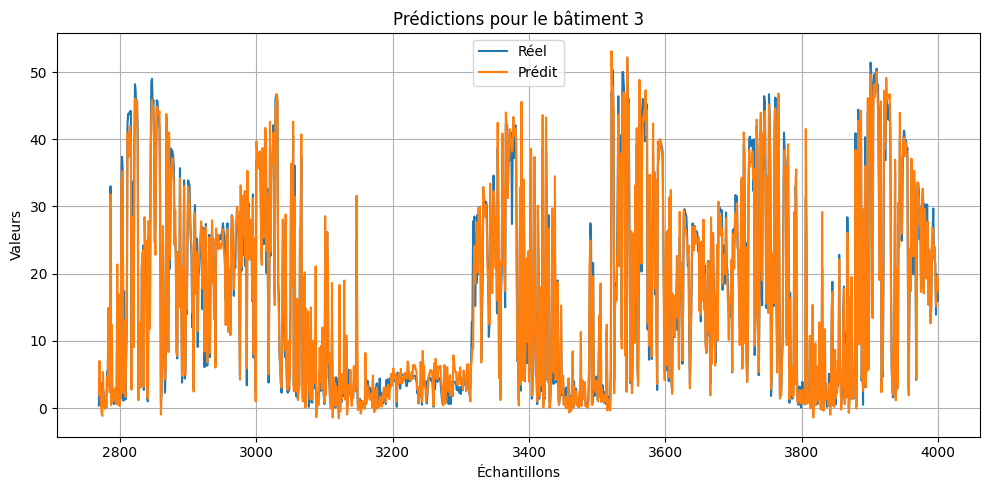

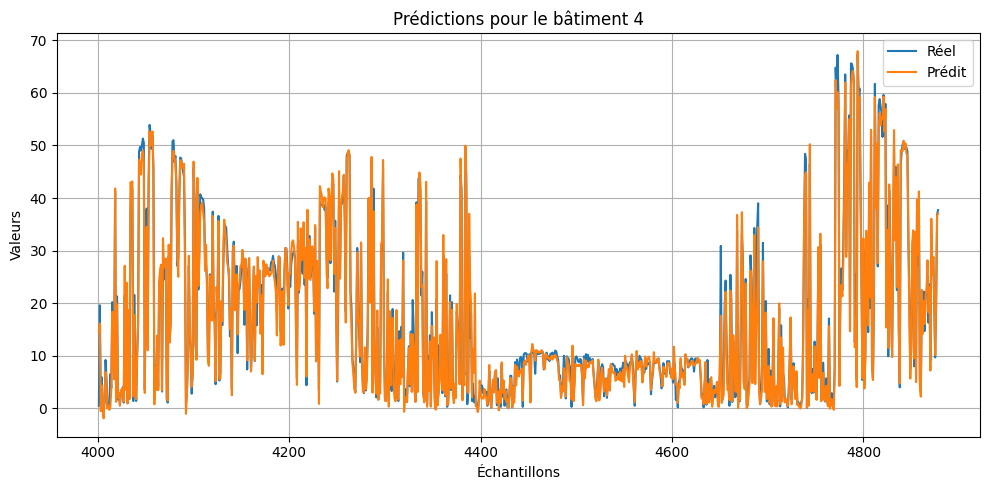

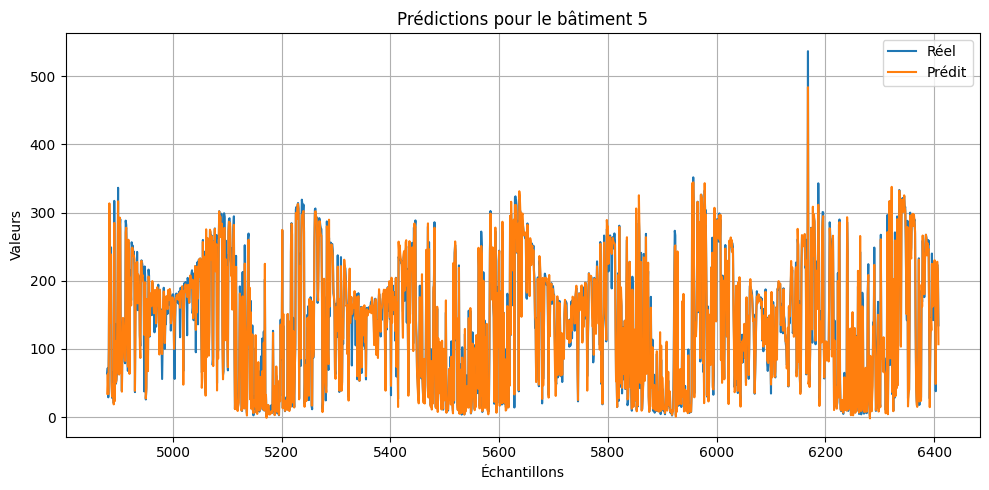

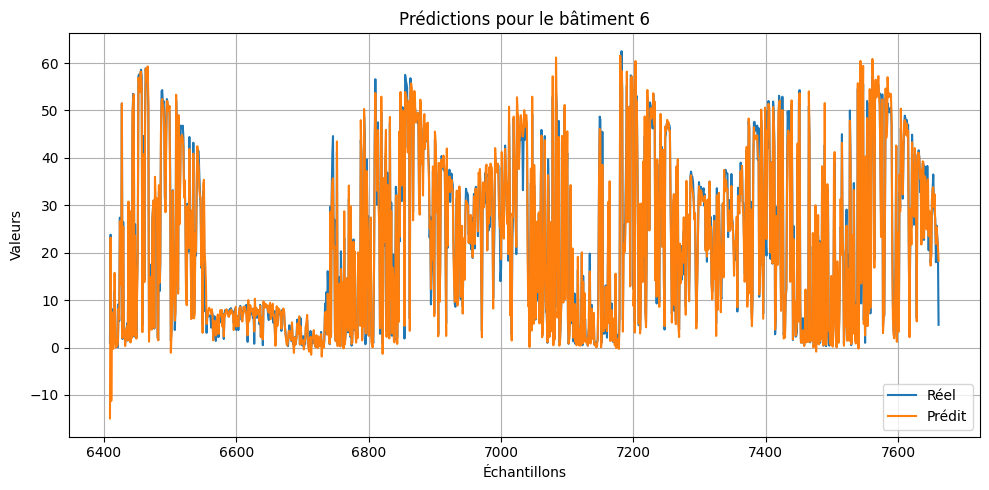

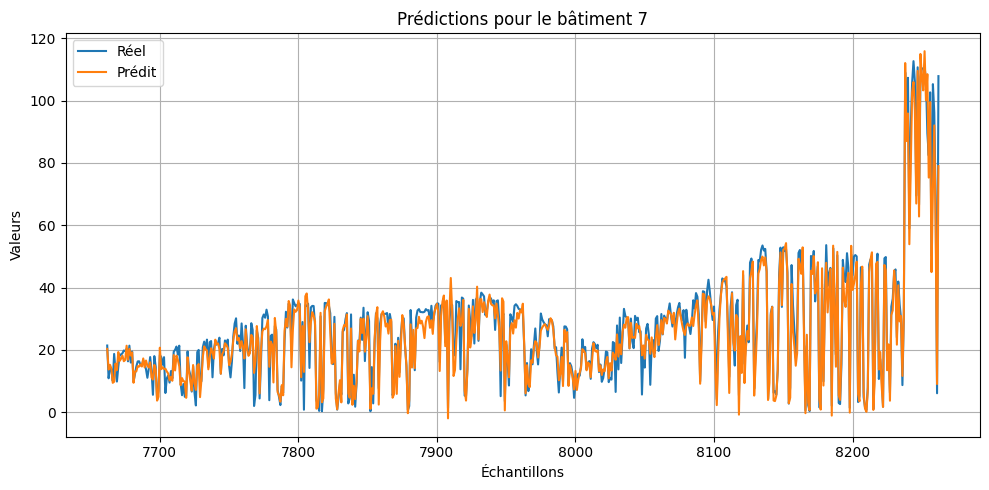

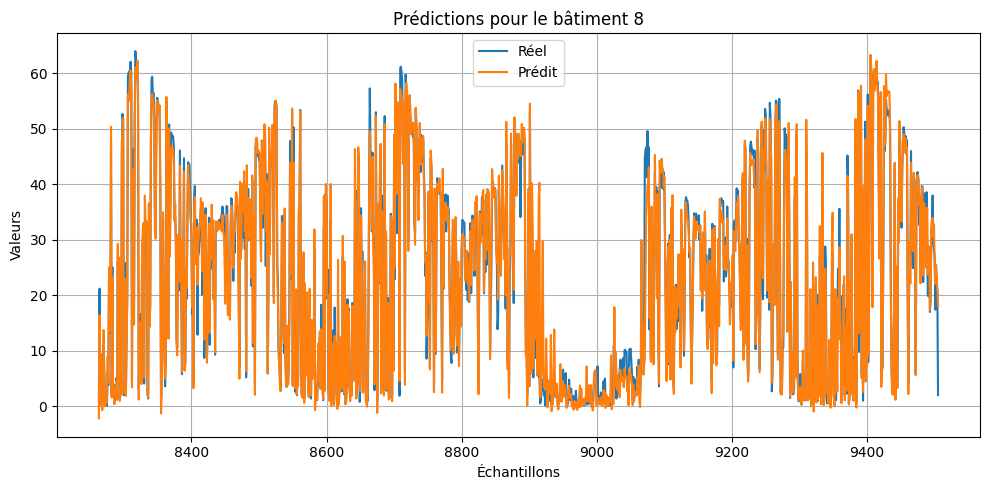

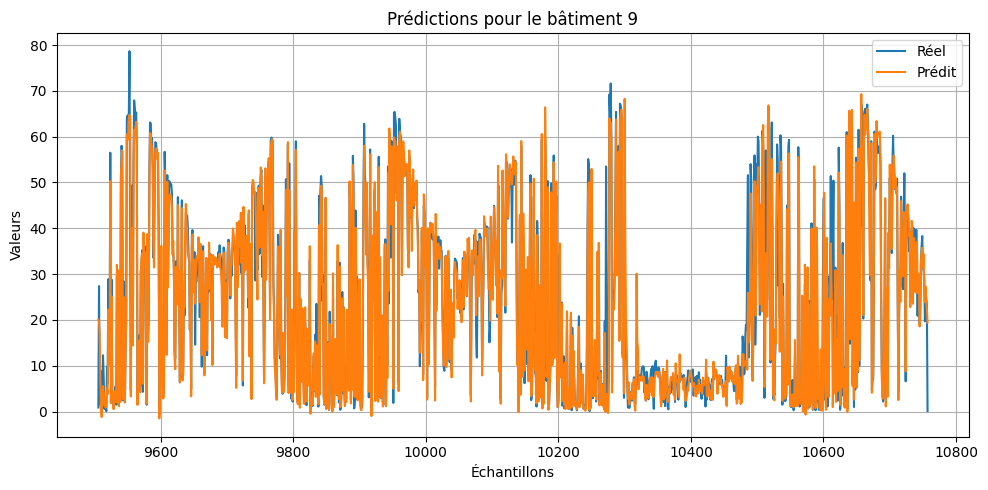

In [27]:
for id in df["building_id"].unique():
    building_df = df[df["building_id"] == id]
    plt.figure(figsize=(10, 5))
    plt.plot(building_df["Production_réelle"], label="Réel")
    plt.plot(building_df["Production_prédite"], label="Prédit")
    plt.title(f"Prédictions pour le bâtiment {id}")
    plt.xlabel("Échantillons")
    plt.ylabel("Valeurs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

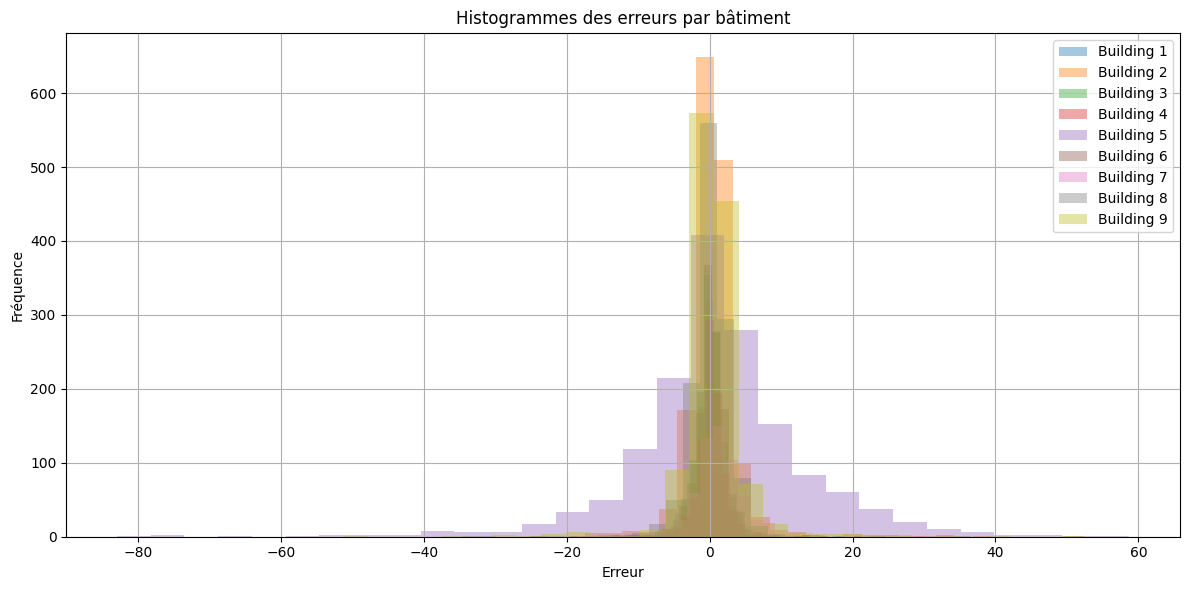

In [28]:
plt.figure(figsize=(12, 6))

for i, id in enumerate(df["building_id"].unique()):
    building_df = df[df["building_id"] == id]
    plt.hist(
        building_df["Erreur"],
        bins=30,
        alpha=0.4,
        label=f"Building {id}",
        histtype='stepfilled'  # optionnel : pour plus de clarté
    )

plt.title("Histogrammes des erreurs par bâtiment")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("hist_erreur_par_building.png")
plt.show()

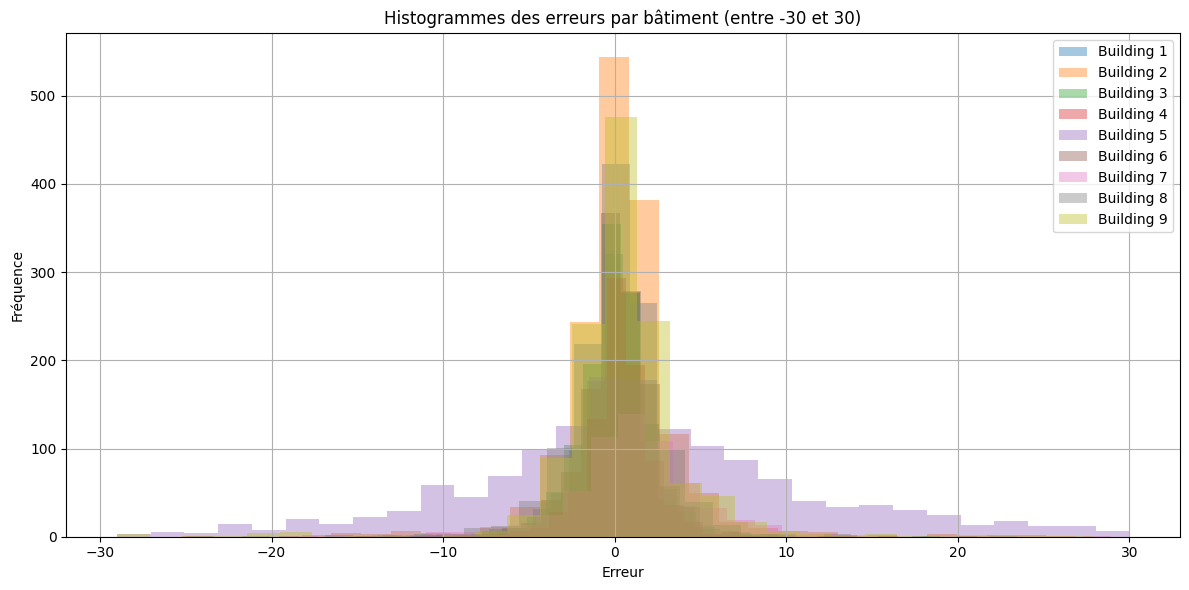

In [30]:
plt.figure(figsize=(12, 6))

for i, id in enumerate(df["building_id"].unique()):
    building_df = df[df["building_id"] == id]
    
    # Filtrer les erreurs entre -40 et 40
    filtered_errors = building_df["Erreur"][
        (building_df["Erreur"] >= -30) & (building_df["Erreur"] <= 30)
    ]
    
    plt.hist(
        filtered_errors,
        bins=30,
        alpha=0.4,
        label=f"Building {id}",
        histtype='stepfilled'
    )

plt.title("Histogrammes des erreurs par bâtiment (entre -30 et 30)")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("hist_erreur_par_building_filtré.png")
plt.show()
